In [14]:
pip install tensorflow pandas numpy requests scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.


In [15]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense
import requests
import datetime

In [16]:
import requests

def fetch_weather_data(api_key, city):
    url = f'http://api.openweathermap.org/data/2.5/weather?q={city}&appid={api_key}&units=metric'
    response = requests.get(url)
    data = response.json()

    weather_data = {
        'temp': data['main']['temp'],
        'rain_1h': data.get('rain', {}).get('1h', 0),
        'snow_1h': data.get('snow', {}).get('1h', 0),
        'clouds_all': data['clouds']['all']
    }

    return weather_data


In [17]:
def prepare_real_time_input(weather_data, hour_of_day, day_of_week, is_weekend, time_steps=10):
    # Time-related features (do not scale these)
    time_features = np.array([hour_of_day, day_of_week, is_weekend])

    # Weather features (scale these)
    weather_features = np.array([weather_data['temp'], weather_data['rain_1h'], 
                                 weather_data['snow_1h'], weather_data['clouds_all']])

    # Combine the time-related features with weather features (ensure consistent shape)
    input_features = np.concatenate([time_features, weather_features], axis=0).reshape(1, -1)

    # Scale only the weather features using the scaler (which was fitted only on the weather features)
    weather_scaled = scaler.transform(weather_features.reshape(1, -1))

    # Recreate the input features by combining time-related and scaled weather features
    scaled_input = np.concatenate([time_features, weather_scaled.flatten()], axis=0).reshape(1, -1)

    # Repeat the input data to create a sequence of length `time_steps`
    scaled_input_sequence = np.repeat(scaled_input, time_steps, axis=0).reshape(1, time_steps, scaled_input.shape[1])

    return scaled_input_sequence

In [18]:
def create_lstm_model(input_shape):
    model = Sequential()
    model.add(LSTM(units=50, return_sequences=True, input_shape=input_shape))
    model.add(LSTM(units=50, return_sequences=False))
    model.add(Dense(units=1))  # Output layer for regression task
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model


In [19]:
import pandas as pd

data = pd.read_csv('Metro_Interstate_Traffic_Volume.csv')

In [20]:
import pandas as pd

data['date_time'] = pd.to_datetime(data['date_time'])


In [21]:
data['hour_of_day'] = data['date_time'].dt.hour
data['day_of_week'] = data['date_time'].dt.dayofweek  # 0=Monday, 6=Sunday
data['is_weekend'] = data['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

In [22]:
features = data[['hour_of_day', 'day_of_week', 'is_weekend', 'temp', 'rain_1h', 'snow_1h', 'clouds_all']].values
labels = data['traffic_volume'].values

In [23]:
train_size = int(len(features) * 0.8)
X_train, X_test = features[:train_size], features[train_size:]
y_train, y_test = labels[:train_size], labels[train_size:]

In [24]:
scaler = MinMaxScaler()
X_train_weather = X_train[:, 3:]  # Extract weather features (temp, rain, snow, clouds)
scaler.fit(X_train_weather)


,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
Name,Type,Value
"data_max_ data_max_: ndarray of shape (n_features,)Per feature maximum seen in the data.. versionadded:: 0.17 *data_max_*","ndarray[float64](4,)","[ 308.24,9831.3 , 0.51, 100. ]"
"data_min_ data_min_: ndarray of shape (n_features,)Per feature minimum seen in the data.. versionadded:: 0.17 *data_min_*","ndarray[float64](4,)","[0.,0.,0.,0.]"
"data_range_ data_range_: ndarray of shape (n_features,)Per feature range ``(data_max_ - data_min_)`` seen in the data.. versionadded:: 0.17 *data_range_*","ndarray[float64](4,)","[ 308.24,9831.3 , 0.51, 100. ]"
"min_ min_: ndarray of shape (n_features,)Per feature adjustment for minimum. Equivalent to``min - X.min(axis=0) * self.scale_``","ndarray[float64](4,)","[0.,0.,0.,0.]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
"n_samples_seen_ n_samples_seen_: intThe number of samples processed by the estimator.It will be reset on new calls to fit, but increments across``partial_fit`` calls.",int,38563
"scale_ scale_: ndarray of shape (n_features,)Per feature relative scaling of the data. Equivalent to``(max - min) / (X.max(axis=0) - X.min(axis=0))``.. versionadded:: 0.17 *scale_* attribute.","ndarray[float64](4,)","[0. ,0. ,1.96,0.01]"


In [25]:
X_train_weather_scaled = scaler.transform(X_train_weather)
X_train_scaled = np.concatenate([X_train[:, :3], X_train_weather_scaled], axis=1)

In [26]:
time_steps = 10  # Number of time steps in the input sequence
X_train_scaled = X_train_scaled.reshape(X_train_scaled.shape[0], 1, X_train_scaled.shape[1])

In [27]:
model = create_lstm_model(X_train_scaled.shape[1:])
model.fit(X_train_scaled, y_train, epochs=10, batch_size=32)

Epoch 1/10


C:\Users\Shoaib Jamal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1206/1206 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 14384181.0000
Epoch 2/10
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 14072649.0000
Epoch 3/10
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 13778155.0000
Epoch 4/10
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 13489690.0000
Epoch 5/10
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 13206201.0000
Epoch 6/10
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 12927129.0000
Epoch 7/10
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 12652540.0000
Epoch 8/10
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 12382404.0000
Epoch 9/10
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 12116427.0000
Epoch 10/10
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 11854790.0000


In [28]:
api_key = 'd165ab6002938d8c5bb06cd0b3aa8973'  # Replace with your actual API key
city = 'New York'
weather_data = fetch_weather_data(api_key, city)

In [29]:
real_time_data = prepare_real_time_input(weather_data, hour_of_day=12, day_of_week=2, is_weekend=0)
real_time_prediction = model.predict(real_time_data)
print(f"Predicted Traffic Volume: {real_time_prediction[0][0]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step
Predicted Traffic Volume: 613.59619140625


In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot

In [31]:
X_test_weather = X_test[:, 3:]
X_test_weather_scaled = scaler.transform(X_test_weather)
X_test_scaled = np.concatenate([X_test[:, :3], X_test_weather_scaled], axis=1)
X_test_scaled = X_test_scaled.reshape(X_test_scaled.shape[0], 1, X_test_scaled.shape[1])

In [32]:
y_pred = model.predict(X_test_scaled)

302/302 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


302/302 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Mean Absolute Error: 2808.793701171875
Mean Squared Error: 11599251.0
Root Mean Squared Error: 3405.7673144241667


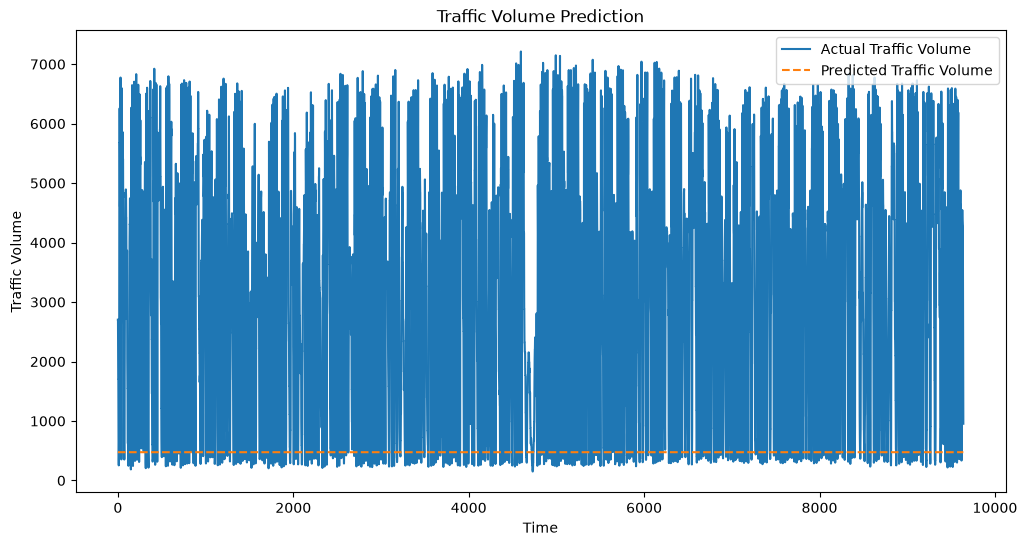

In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# Scale the test data
X_test_weather = X_test[:, 3:]
X_test_weather_scaled = scaler.transform(X_test_weather)
X_test_scaled = np.concatenate([X_test[:, :3], X_test_weather_scaled], axis=1)
X_test_scaled = X_test_scaled.reshape(X_test_scaled.shape[0], 1, X_test_scaled.shape[1])

# Predict on the test set
y_pred = model.predict(X_test_scaled)

# Calculate MAE, MSE, RMSE
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")

# Visualize predictions
plt.figure(figsize=(12, 6))
plt.plot(y_test, label='Actual Traffic Volume')
plt.plot(y_pred, label='Predicted Traffic Volume', linestyle='--')
plt.legend()
plt.title("Traffic Volume Prediction")
plt.xlabel("Time")
plt.ylabel("Traffic Volume")
plt.show()

In [43]:
model.save('traffic_volume_predictor.keras')

In [44]:
from tensorflow.keras.models import load_model

# Load the modern .keras file
model = load_model('traffic_volume_predictor.keras')

C:\Users\Shoaib Jamal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\saving\saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 18 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [36]:
import logging
import datetime
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Set up logging to both console and file
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler('model_performance.log'),  # File handler
        logging.StreamHandler()  # Console handler
    ]
)

# Log a test message
logging.info("Logging started successfully.")

# Function to log performance metrics
def log_performance(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    logging.info(f"MAE: {mae}, MSE: {mse}, RMSE: {rmse}, Time: {datetime.datetime.now()}")

# Placeholder for data preprocessing and model creation
def preprocess_data(data):
    # Assuming 'traffic_volume' is the target and rest are features
    features = data.drop(['traffic_volume'], axis=1).values  # Drop target column
    labels = data['traffic_volume'].values  # Target column
    return features, labels

def scale_data(data):
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    return scaler.fit_transform(data)

def create_lstm_model(input_shape):
    from keras.models import Sequential
    from keras.layers import LSTM, Dense

    model = Sequential()
    model.add(LSTM(units=50, return_sequences=False, input_shape=input_shape))
    model.add(Dense(units=1))  # Output layer for regression
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Function to retrain the model
def retrain_model():
    # Load new data
    new_data = pd.read_csv('Metro_Interstate_Traffic_Volume.csv')  # Replace with the path to the fresh data
    
    # Process the data (same preprocessing steps as before)
    features, labels = preprocess_data(new_data)
    
    # Normalize the features
    scaler = scale_data(features)
    
    # Reshape data for LSTM (assuming that data needs to be 3D for LSTM)
    features_scaled = scaler.reshape(features.shape[0], 1, features.shape[1])
    
    # Retrain the model
    model = create_lstm_model(features_scaled.shape[1:])
    model.fit(features_scaled, labels, epochs=10, batch_size=32)
    
    # Save the retrained model
    model.save('traffic_volume_predictor_retrained.h5')
    print("Model retrained successfully!")

# Log performance metrics
log_performance(y_test, y_pred)

# Read and print the contents of the log file to verify
try:
    with open('model_performance.log', 'r') as file:
        log_contents = file.read()
        print(log_contents)  # Print log contents to the console
except FileNotFoundError:
    print("Log file not found. Please check if logging is set up correctly.")


In [37]:
#  Traditional Machine Learning Models (Baseline Comparison)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler  # Added import

# Prepare 2D data (NOT LSTM data)
X_ml = data[['hour_of_day', 'day_of_week', 'is_weekend',
             'temp', 'rain_1h', 'snow_1h', 'clouds_all']]
y_ml = data['traffic_volume']

# Train-test split
split = int(len(X_ml) * 0.8)
X_train_ml, X_test_ml = X_ml[:split].copy(), X_ml[split:].copy()
y_train_ml, y_test_ml = y_ml[:split], y_ml[split:]

# 1. Define columns to scale
cols_to_scale = ['temp', 'rain_1h', 'snow_1h', 'clouds_all']

# 2. Convert weather columns to float by replacing the Series (prevents LossySetitemError)
for col in cols_to_scale:
    X_train_ml[col] = X_train_ml[col].astype(float)
    X_test_ml[col] = X_test_ml[col].astype(float)

# 3. Apply the scaler safely
scaler_ml = MinMaxScaler()
X_train_ml[cols_to_scale] = scaler_ml.fit_transform(X_train_ml[cols_to_scale])
X_test_ml[cols_to_scale] = scaler_ml.transform(X_test_ml[cols_to_scale])




In [38]:
lr = LinearRegression()
lr.fit(X_train_ml, y_train_ml)

lr_preds = lr.predict(X_test_ml)
print("Linear Regression MSE:", mean_squared_error(y_test_ml, lr_preds))


Linear Regression MSE: 3152079.167146733


In [39]:
dt_reg = DecisionTreeRegressor(max_depth=10)
dt_reg.fit(X_train_ml, y_train_ml)

dt_preds = dt_reg.predict(X_test_ml)
print("Decision Tree Regression MSE:", mean_squared_error(y_test_ml, dt_preds))


Decision Tree Regression MSE: 300650.25745126687


In [40]:
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train_ml, y_train_ml)

rf_preds = rf_reg.predict(X_test_ml)
print("Random Forest Regression MSE:", mean_squared_error(y_test_ml, rf_preds))


Random Forest Regression MSE: 330494.5483210678


In [41]:
#  Traffic Level Classification Models
# Create traffic level classes
data['traffic_level'] = pd.cut(
    data['traffic_volume'],
    bins=[0, 2000, 4000, 7000],
    labels=[0, 1, 2]
)

X_cls = data[['hour_of_day', 'day_of_week', 'is_weekend',
              'temp', 'rain_1h', 'snow_1h', 'clouds_all']]
y_cls = data['traffic_level']

split = int(len(X_cls) * 0.8)
# --- FIX 1: Use .copy() to prevent SettingWithCopyWarning ---
X_train_c, X_test_c = X_cls[:split].copy(), X_cls[split:].copy()
y_train_c, y_test_c = y_cls[:split], y_cls[split:]

# --- FIX 2: Safely convert weather columns to float and scale by name (prevents LossySetitemError) ---
cols_to_scale = ['temp', 'rain_1h', 'snow_1h', 'clouds_all']
for col in cols_to_scale:
    X_train_c[col] = X_train_c[col].astype(float)
    X_test_c[col] = X_test_c[col].astype(float)

X_train_c[cols_to_scale] = scaler_ml.fit_transform(X_train_c[cols_to_scale])
X_test_c[cols_to_scale] = scaler_ml.transform(X_test_c[cols_to_scale])



In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import MinMaxScaler

# Create Traffic Level Classes 
data['traffic_level'] = pd.cut(
    data['traffic_volume'],
    bins=[0, 2000, 4000, 7000],
    labels=[0, 1, 2],
    include_lowest=True
)

#  DROP NaNs FIRST (CRITICAL FIX)
data = data.dropna(subset=['traffic_level'])

#  NOW convert to int
data['traffic_level'] = data['traffic_level'].astype(int)

#  Prepare Classification Data 
X_cls = data[['hour_of_day', 'day_of_week', 'is_weekend',
              'temp', 'rain_1h', 'snow_1h', 'clouds_all']]
y_cls = data['traffic_level']

# Ensure no NaNs anywhere
X_cls = X_cls.fillna(0)
y_cls = y_cls.fillna(0)

split = int(len(X_cls) * 0.8)
# --- FIX 1: Added .copy() to prevent SettingWithCopyWarning ---
X_train_c, X_test_c = X_cls[:split].copy(), X_cls[split:].copy()
y_train_c, y_test_c = y_cls[:split], y_cls[split:]

# --- FIX 2: Safely convert weather columns to float and scale by name (prevents LossySetitemError) ---
cols_to_scale = ['temp', 'rain_1h', 'snow_1h', 'clouds_all']
for col in cols_to_scale:
    X_train_c[col] = X_train_c[col].astype(float)
    X_test_c[col] = X_test_c[col].astype(float)

scaler_cls = MinMaxScaler()
X_train_c[cols_to_scale] = scaler_cls.fit_transform(X_train_c[cols_to_scale])
X_test_c[cols_to_scale] = scaler_cls.transform(X_test_c[cols_to_scale])

# ---------- Step 7: Logistic Regression ----------
log_reg = LogisticRegression(
    max_iter=3000,
    solver='lbfgs',
)

log_reg.fit(X_train_c, y_train_c)

# ---------- Step 8: Predict & Evaluate ----------
log_preds = log_reg.predict(X_test_c)
accuracy = accuracy_score(y_test_c, log_preds)

print(" Logistic Regression Accuracy:", accuracy)



 Logistic Regression Accuracy: 0.6706823138435974
